# Notebook 14 - Facies-Aware Cluster Modeling\n
\n
This notebook compares three strategies: global baseline, local experts by cluster, and hybrid global-plus-cluster features under random split, GroupKFold, and spatial holdout protocols.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from xgboost import XGBRegressor
except Exception:
    XGBRegressor = None

NOTEBOOK_ROOT = Path.cwd() if Path.cwd().name == "14_facies_cluster_modeling_no_scripts" else Path(r"c:/Users/obalo/Downloads/PhDOneDrive/PhD_Research_Operating_System/github_org_bootstrap/phd-geothermal-ml/manual_bootstrap/step_by_step_notebooks/14_facies_cluster_modeling_no_scripts")
PROJECT_ROOT = NOTEBOOK_ROOT.parents[2]
PHD_OS_ROOT = PROJECT_ROOT.parents[1]
OUTPUT_ROOT = NOTEBOOK_ROOT / "outputs" / "summary"
TABLE_ROOT = OUTPUT_ROOT / "tables"
REPORT_ROOT = OUTPUT_ROOT / "reports"
TABLE_ROOT.mkdir(parents=True, exist_ok=True)
REPORT_ROOT.mkdir(parents=True, exist_ok=True)

data_candidates = [
    PROJECT_ROOT / "datasets" / "geothermal_canonical_v2_0_0.csv",
    PHD_OS_ROOT / "03_data_processed" / "geothermal_canonical_v2_0_0.csv",
    PHD_OS_ROOT / "02_data_raw" / "geothermal_canonical_v2_0_0.csv",
    PHD_OS_ROOT / "incoming_from_legacy" / "geothermal_canonical_v2_0_0.csv",
]
data_path = next((p for p in data_candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find geothermal_canonical_v2_0_0.csv in expected locations.")

df = pd.read_csv(data_path)
TARGET = "Temperature(C)"
GROUP_COL = "State"
X_raw = df.drop(columns=[TARGET]).copy()
y_all = df[TARGET].copy()
groups_all = df[GROUP_COL].astype(str).copy() if GROUP_COL in df.columns else pd.Series(["ALL"] * len(df))

feature_cols = [c for c in X_raw.columns if c != GROUP_COL]
X_model = X_raw[feature_cols].copy()
numeric_cols = X_model.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_model.columns if c not in numeric_cols]

num_pipe = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
cat_pipe = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])
preprocess = ColumnTransformer([("num", num_pipe, numeric_cols), ("cat", cat_pipe, categorical_cols)], remainder="drop")

if XGBRegressor is None:
    xgb = ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1)
else:
    xgb = XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=5, subsample=0.9, colsample_bytree=0.9, objective="reg:squarederror", random_state=42, n_jobs=4)

global_reg = VotingRegressor([
    ("gbm", GradientBoostingRegressor(random_state=42, n_estimators=350, learning_rate=0.05, max_depth=3)),
    ("xgb", xgb),
    ("et", ExtraTreesRegressor(n_estimators=400, random_state=42, n_jobs=-1))
])


def fit_transform_train_test(X_tr_raw, X_te_raw):
    X_tr = preprocess.fit_transform(X_tr_raw)
    X_te = preprocess.transform(X_te_raw)
    return X_tr, X_te


def run_split(X_tr_raw, y_tr, X_te_raw, y_te, protocol, split_id, n_clusters=4):
    X_tr, X_te = fit_transform_train_test(X_tr_raw, X_te_raw)

    # Global model
    global_reg.fit(X_tr, y_tr)
    pred_global = global_reg.predict(X_te)
    rmse_global = float(np.sqrt(mean_squared_error(y_te, pred_global)))
    r2_global = float(r2_score(y_te, pred_global))

    # Cluster model
    scaler = StandardScaler(with_mean=False)
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
    tr_clusters = km.fit_predict(X_tr_scaled)
    te_clusters = km.predict(X_te_scaled)

    local_models = {}
    for c in range(n_clusters):
        idx = np.where(tr_clusters == c)[0]
        if len(idx) < 25:
            continue
        m = GradientBoostingRegressor(random_state=42, n_estimators=300, learning_rate=0.05, max_depth=3)
        m.fit(X_tr[idx], y_tr.iloc[idx])
        local_models[c] = m

    pred_local = np.empty(X_te.shape[0], dtype=float)
    fallback_pred = pred_global
    for i in range(X_te.shape[0]):
        c = int(te_clusters[i])
        if c in local_models:
            pred_local[i] = local_models[c].predict(X_te[i:i + 1])[0]
        else:
            pred_local[i] = fallback_pred[i]

    rmse_local = float(np.sqrt(mean_squared_error(y_te, pred_local)))
    r2_local = float(r2_score(y_te, pred_local))

    # Hybrid model: add cluster IDs as one-hot
    tr_onehot = np.zeros((X_tr.shape[0], n_clusters), dtype=float)
    tr_onehot[np.arange(X_tr.shape[0]), tr_clusters] = 1.0
    te_onehot = np.zeros((X_te.shape[0], n_clusters), dtype=float)
    te_onehot[np.arange(X_te.shape[0]), te_clusters] = 1.0

    from scipy import sparse
    if sparse.issparse(X_tr):
        X_tr_hybrid = sparse.hstack([X_tr, sparse.csr_matrix(tr_onehot)], format="csr")
        X_te_hybrid = sparse.hstack([X_te, sparse.csr_matrix(te_onehot)], format="csr")
    else:
        X_tr_hybrid = np.hstack([X_tr, tr_onehot])
        X_te_hybrid = np.hstack([X_te, te_onehot])

    global_reg.fit(X_tr_hybrid, y_tr)
    pred_hybrid = global_reg.predict(X_te_hybrid)
    rmse_hybrid = float(np.sqrt(mean_squared_error(y_te, pred_hybrid)))
    r2_hybrid = float(r2_score(y_te, pred_hybrid))

    out = [
        {"strategy": "global_baseline", "protocol": protocol, "split_id": split_id, "rmse": rmse_global, "r2": r2_global},
        {"strategy": "local_experts", "protocol": protocol, "split_id": split_id, "rmse": rmse_local, "r2": r2_local},
        {"strategy": "hybrid_global_local", "protocol": protocol, "split_id": split_id, "rmse": rmse_hybrid, "r2": r2_hybrid},
    ]

    # per-cluster eval for local model
    cluster_rows = []
    for c in range(n_clusters):
        mask = te_clusters == c
        if np.sum(mask) < 10:
            continue
        y_c = y_te.values[mask]
        p_c = pred_local[mask]
        cluster_rows.append({
            "protocol": protocol,
            "split_id": split_id,
            "cluster_id": int(c),
            "support_n": int(np.sum(mask)),
            "rmse": float(np.sqrt(mean_squared_error(y_c, p_c))),
            "r2": float(r2_score(y_c, p_c))
        })

    return out, cluster_rows


rows = []
cluster_rows_all = []

# Random split
for seed in range(10):
    idx = np.arange(len(X_model))
    tr_idx, te_idx = train_test_split(idx, test_size=0.2, random_state=seed)
    out, crows = run_split(X_model.iloc[tr_idx], y_all.iloc[tr_idx], X_model.iloc[te_idx], y_all.iloc[te_idx], "random_split", seed)
    rows.extend(out)
    cluster_rows_all.extend(crows)

# GroupKFold
gkf = GroupKFold(n_splits=5)
for fold_idx, (tr_idx, te_idx) in enumerate(gkf.split(X_model, y_all, groups=groups_all), start=1):
    out, crows = run_split(X_model.iloc[tr_idx], y_all.iloc[tr_idx], X_model.iloc[te_idx], y_all.iloc[te_idx], "groupkfold", fold_idx)
    rows.extend(out)
    cluster_rows_all.extend(crows)

# Spatial holdout
group_counts = groups_all.value_counts()
eligible_groups = group_counts[group_counts >= 30].index.tolist()
for g in eligible_groups:
    te_mask = groups_all == g
    tr_idx = np.where(~te_mask.values)[0]
    te_idx = np.where(te_mask.values)[0]
    if len(te_idx) < 30 or len(tr_idx) < 100:
        continue
    out, crows = run_split(X_model.iloc[tr_idx], y_all.iloc[tr_idx], X_model.iloc[te_idx], y_all.iloc[te_idx], "spatial_holdout", str(g))
    rows.extend(out)
    cluster_rows_all.extend(crows)

runs_df = pd.DataFrame(rows)
cluster_df = pd.DataFrame(cluster_rows_all)
summary = runs_df.groupby(["strategy", "protocol"], as_index=False)[["rmse", "r2"]].mean()
leaderboard = summary.copy()
leaderboard["rank_within_protocol"] = leaderboard.groupby("protocol")["rmse"].rank(method="dense")
weights = {"random_split": 0.2, "groupkfold": 0.4, "spatial_holdout": 0.4}
leaderboard["weighted_component"] = leaderboard["protocol"].map(weights) * leaderboard["rank_within_protocol"]
weighted = leaderboard.groupby("strategy", as_index=False)["weighted_component"].sum().rename(columns={"weighted_component": "weighted_score"}).sort_values("weighted_score")

runs_df.to_csv(TABLE_ROOT / "all_runs_facies_modeling.csv", index=False)
summary.to_csv(TABLE_ROOT / "protocol_summary_facies_modeling.csv", index=False)
weighted.to_csv(TABLE_ROOT / "weighted_leaderboard_facies_modeling.csv", index=False)
if not cluster_df.empty:
    cluster_df.to_csv(TABLE_ROOT / "per_cluster_metrics_facies_modeling.csv", index=False)

lines = [
    "# Notebook 14 Facies Modeling Summary",
    "",
    f"Runs rows: {len(runs_df)}",
    f"Per-cluster rows: {len(cluster_df)}",
    "",
    "## Weighted leaderboard",
]
for _, r in weighted.iterrows():
    lines.append(f"- {r['strategy']}: weighted_score={r['weighted_score']:.4f}")
(REPORT_ROOT / "facies_interpretation_notes.md").write_text("\n".join(lines), encoding="utf-8")

print("Saved:", TABLE_ROOT / "all_runs_facies_modeling.csv")
print("Saved:", TABLE_ROOT / "protocol_summary_facies_modeling.csv")
print("Saved:", TABLE_ROOT / "weighted_leaderboard_facies_modeling.csv")
if not cluster_df.empty:
    print("Saved:", TABLE_ROOT / "per_cluster_metrics_facies_modeling.csv")
print("Saved:", REPORT_ROOT / "facies_interpretation_notes.md")
weighted

Saved: c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\github_org_bootstrap\phd-geothermal-ml\manual_bootstrap\step_by_step_notebooks\14_facies_cluster_modeling_no_scripts\outputs\summary\tables\all_runs_facies_modeling.csv
Saved: c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\github_org_bootstrap\phd-geothermal-ml\manual_bootstrap\step_by_step_notebooks\14_facies_cluster_modeling_no_scripts\outputs\summary\tables\protocol_summary_facies_modeling.csv
Saved: c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\github_org_bootstrap\phd-geothermal-ml\manual_bootstrap\step_by_step_notebooks\14_facies_cluster_modeling_no_scripts\outputs\summary\tables\weighted_leaderboard_facies_modeling.csv
Saved: c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\github_org_bootstrap\phd-geothermal-ml\manual_bootstrap\step_by_step_notebooks\14_facies_cluster_modeling_no_scripts\outputs\summary\tables\per_cluster_metrics_facies_modeling.c

,strategy,weighted_score
2,local_experts,1.4
1,hybrid_global_local,2.0
0,global_baseline,2.6


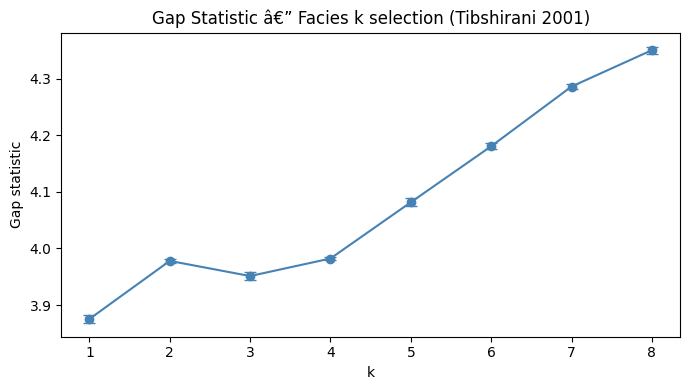

=== N9.1+N9.8+N6.9 Gap statistic optimal k: 8 ===


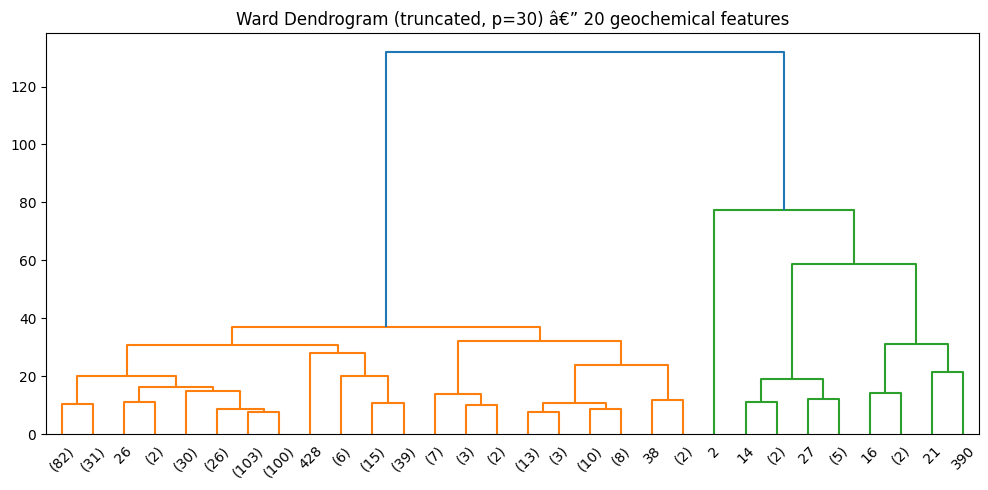

Use k=8 in KMeans for facies clustering (Paper 7/8).


In [2]:
# N9.1 + N9.8 + N6.9 â€” Gap statistic (Tibshirani 2001) + Ward dendrogram for facies k selection
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from scipy.cluster import hierarchy

_data_path = Path(r'c:/Users/obalo/Downloads/PhDOneDrive/PhD_Research_Operating_System/03_data_processed/geothermal_canonical_v2_0_0.csv')
_df = pd.read_csv(_data_path)
_TARGET = 'Temperature(C)'
_feat_cols = [c for c in _df.select_dtypes(include=[np.number]).columns if c != _TARGET]

_X_imp = SimpleImputer(strategy='median').fit_transform(_df[_feat_cols])
_X_sc = StandardScaler().fit_transform(_X_imp)


def _gap_statistic(X, k_range=range(1, 9), n_ref=5, seed=42):
    """Tibshirani 2001 gap statistic for principled k selection."""
    rng = np.random.default_rng(seed)
    _gaps, _sks = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=seed, n_init=10)
        labels = km.fit_predict(X)
        _wk = sum(np.sum((X[labels == c] - X[labels == c].mean(axis=0)) ** 2)
                  for c in range(k) if np.sum(labels == c) > 0)
        _ref_wks = []
        for _ in range(n_ref):
            X_ref = rng.uniform(X.min(axis=0), X.max(axis=0), size=X.shape)
            km_ref = KMeans(n_clusters=k, random_state=seed, n_init=5)
            lbl_ref = km_ref.fit_predict(X_ref)
            _ref_wks.append(sum(np.sum((X_ref[lbl_ref == c] - X_ref[lbl_ref == c].mean(axis=0)) ** 2)
                                for c in range(k) if np.sum(lbl_ref == c) > 0))
        _gaps.append(np.log(np.mean(_ref_wks)) - np.log(_wk))
        _sks.append(np.std(np.log(_ref_wks)) * np.sqrt(1 + 1 / n_ref))
    return list(k_range), _gaps, _sks


_k_vals, _gaps, _sks = _gap_statistic(_X_sc)

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(_k_vals, _gaps, yerr=_sks, marker='o', capsize=4, color='steelblue')
ax.set_xlabel('k'); ax.set_ylabel('Gap statistic')
ax.set_title('Gap Statistic â€” Facies k selection (Tibshirani 2001)')
plt.tight_layout(); plt.savefig('gap_statistic.png', dpi=600); plt.show()

_best_k = _k_vals[int(np.argmax(_gaps))]
print(f"=== N9.1+N9.8+N6.9 Gap statistic optimal k: {_best_k} ===")

# Ward dendrogram (truncated, p=30)
_X_sub = _X_sc[:min(500, len(_X_sc))]
_z = hierarchy.ward(_X_sub)
fig, ax = plt.subplots(figsize=(10, 5))
hierarchy.dendrogram(_z, ax=ax, truncate_mode='lastp', p=30, show_leaf_counts=True)
ax.set_title(f'Ward Dendrogram (truncated, p=30) â€” {len(_feat_cols)} geochemical features')
plt.tight_layout(); plt.savefig('ward_dendrogram_facies.png', dpi=600); plt.show()
print(f"Use k={_best_k} in KMeans for facies clustering (Paper 7/8).")

In [3]:
# N8.5 â€” Environment watermark for reproducibility
try:
    import watermark
    %load_ext watermark
    %watermark -v -p numpy,pandas,scikit-learn,scipy,matplotlib,xgboost
except ImportError:
    import sys, numpy, pandas, sklearn, scipy, matplotlib
    print(f"Python {sys.version}")
    print(f"numpy={numpy.__version__}, pandas={pandas.__version__}")
    print(f"scikit-learn={sklearn.__version__}, scipy={scipy.__version__}")
    print(f"matplotlib={matplotlib.__version__}")
    try:
        import xgboost; print(f"xgboost={xgboost.__version__}")
    except ImportError:
        pass

Python implementation: CPython
Python version       : 3.12.10
IPython version      : 9.11.0

numpy       : 2.4.2
pandas      : 2.2.2
scikit-learn: 1.8.0
scipy       : 1.17.1
matplotlib  : 3.10.8
xgboost     : 3.2.0

